# Homework 1 - Part 4: Linear SVM Regressor
### Burak Kurucay - 210104004049
---

This section models a linear SVM regressor on the Bike Sharing hourly dataset.
The model is evaluated with 6-fold cross validation using regression metrics, prediction visualizations,
and runtime analysis.


## Code:

### Import the necessary modules

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_absolute_error, r2_score


### Load the dataset
Load the hourly bike sharing dataset and show the number of rows and columns.

In [2]:
data_path = os.path.abspath("../src/data/hour.csv")
df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))


Dataset shape: (17379, 17)
Columns: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


### Sample the dataset
The original dataset is large for repeated from-scratch style experiments, so sample 2400 rows while preserving the target distribution by stratifying on binned `cnt` values.

In [3]:
df["cnt_bin"] = pd.qcut(df["cnt"], q=10, duplicates="drop")

df, _ = train_test_split(
    df,
    train_size=3000,
    random_state=42,
    stratify=df["cnt_bin"]
)

df = df.drop(columns=["cnt_bin"]).reset_index(drop=True)

print("Sampled dataset shape:", df.shape)


Sampled dataset shape: (3000, 17)


### Prepare the dataset
Use `cnt` as the regression target. Exclude `casual` and `registered` to avoid target leakage, and drop identifier/date columns.

In [4]:
feature_columns = [
    "season", "yr", "mnth", "hr", "holiday", "weekday", "workingday",
    "weathersit", "temp", "atemp", "hum", "windspeed"
]
target_column = "cnt"

X = df[feature_columns].values
y = df[target_column].values


### Monitor the data
Just to see the dataset loaded.

In [5]:
df[feature_columns + [target_column]].head()


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,3,0,8,19,0,3,1,1,0.74,0.6818,0.55,0.2985,440
1,2,1,5,19,0,3,1,3,0.50,0.4848,0.77,0.3582,98
2,1,0,3,17,0,6,0,1,0.46,0.4545,0.44,0.3284,213
3,1,1,3,0,0,0,0,1,0.46,0.4545,0.88,0.1940,107
4,3,1,7,2,0,3,1,1,0.64,0.5758,0.89,0.0000,5


### Train By 6-Fold Cross Validation

In [6]:
kf = KFold(n_splits=6, shuffle=True, random_state=42)

fold_results = []
overall_start_time = time.time()

for fold_idx, (train_index, test_index) in enumerate(kf.split(X), start=1):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", LinearSVR(random_state=42, dual="auto", max_iter=20000))
    ])

    fold_start_time = time.time()
    model.fit(X_train, y_train)
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    fold_end_time = time.time()

    train_rmse = np.sqrt(np.mean((y_train - train_predictions) ** 2))
    test_rmse = np.sqrt(np.mean((y_test - test_predictions) ** 2))

    fold_results.append({
        "fold": fold_idx,
        "train_mae": mean_absolute_error(y_train, train_predictions),
        "test_mae": mean_absolute_error(y_test, test_predictions),
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_r2": r2_score(y_train, train_predictions),
        "test_r2": r2_score(y_test, test_predictions),
        "y_test": y_test,
        "test_predictions": test_predictions,
        "runtime_seconds": fold_end_time - fold_start_time
    })

overall_end_time = time.time()
mean_runtime = np.mean([r["runtime_seconds"] for r in fold_results])
total_runtime = overall_end_time - overall_start_time


## Results:

### Prediction Overview


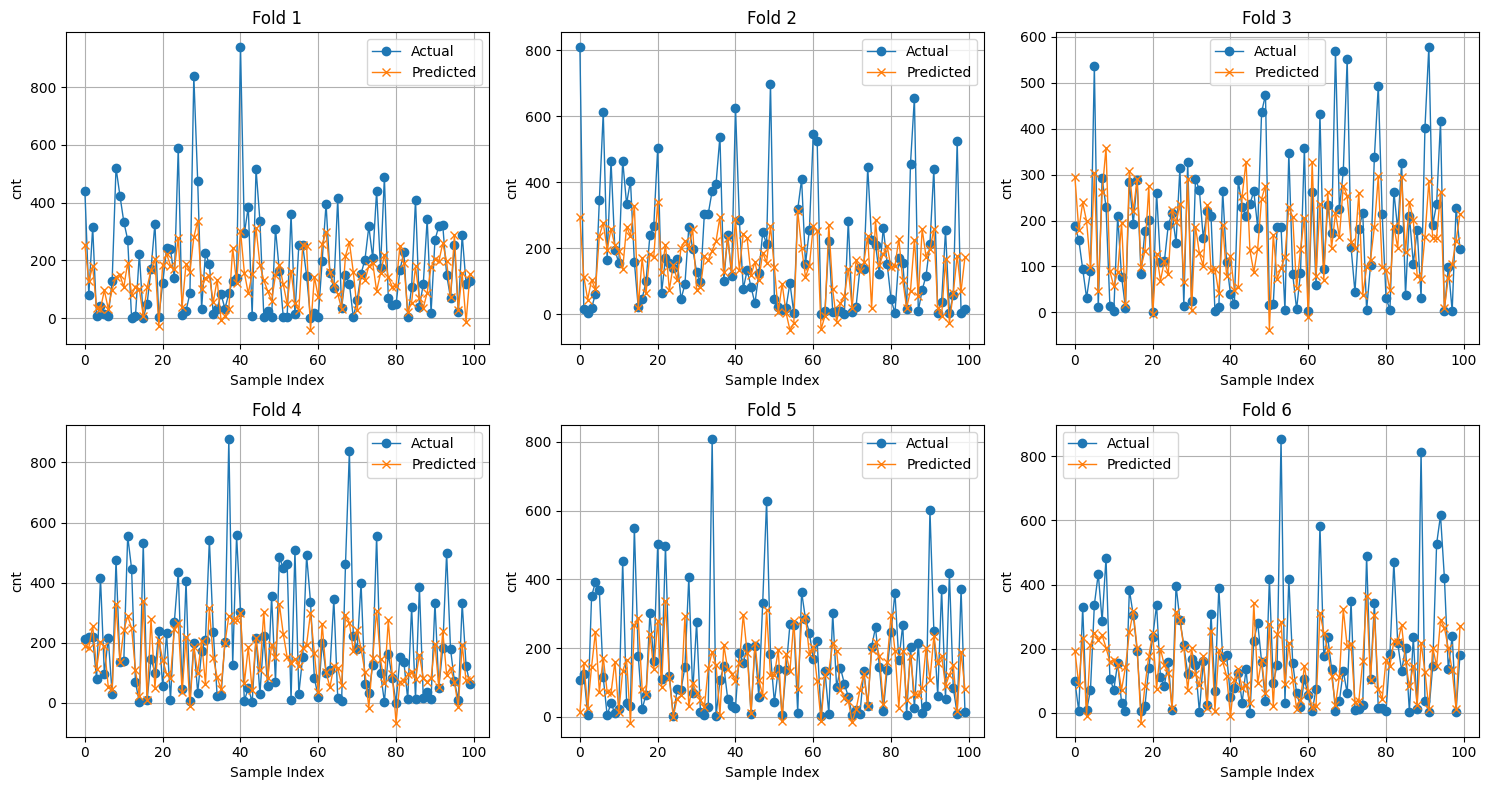

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, result in enumerate(fold_results):
    ax = axes[i]
    y_true = result["y_test"]
    y_pred = result["test_predictions"]

    sample_size = min(100, len(y_true))
    ax.plot(range(sample_size), y_true[:sample_size], marker='o', linewidth=1, label="Actual")
    ax.plot(range(sample_size), y_pred[:sample_size], marker='x', linewidth=1, label="Predicted")
    ax.set_title(f"Fold {result['fold']}")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("cnt")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


### Regression Metrics

,Fold,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,1,100.3453,107.1974,149.5167,156.1366,0.3176,0.3045
1,2,101.0533,103.0245,149.8868,152.1929,0.3199,0.3136
2,3,101.6120,100.3169,150.7153,148.6403,0.3209,0.3013
3,4,101.2207,102.7304,150.1717,152.9164,0.3190,0.2984
4,5,101.1196,103.7783,150.4418,154.5004,0.3092,0.3197
5,6,102.8000,94.6282,152.3413,140.0018,0.3129,0.3428


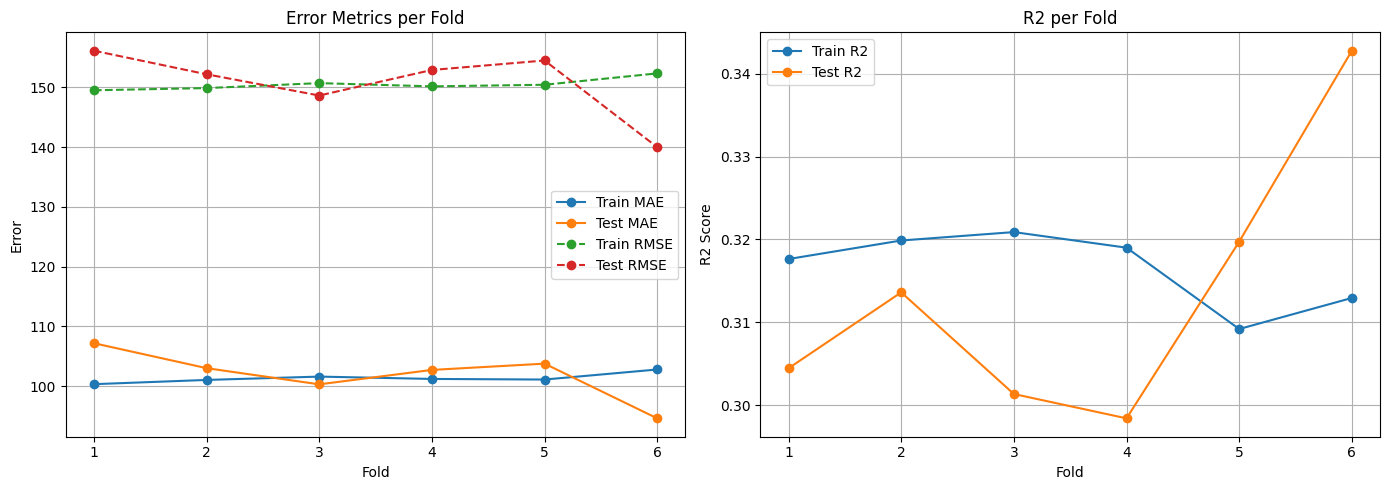

,Metric,Value
0,Mean Train MAE,101.3585
1,Mean Test MAE,101.9460
2,Mean Train RMSE,150.5123
3,Mean Test RMSE,150.7314
4,Mean Train R2,0.3166
5,Mean Test R2,0.3134


In [8]:
metric_rows = []

for result in fold_results:
    metric_rows.append({
        "Fold": result["fold"],
        "Train MAE": result["train_mae"],
        "Test MAE": result["test_mae"],
        "Train RMSE": result["train_rmse"],
        "Test RMSE": result["test_rmse"],
        "Train R2": result["train_r2"],
        "Test R2": result["test_r2"]
    })

df_metrics = pd.DataFrame(metric_rows)
df_metrics.iloc[:, 1:] = df_metrics.iloc[:, 1:].round(4)
display(df_metrics)

folds = [r["fold"] for r in fold_results]
train_maes = [r["train_mae"] for r in fold_results]
test_maes = [r["test_mae"] for r in fold_results]
train_rmses = [r["train_rmse"] for r in fold_results]
test_rmses = [r["test_rmse"] for r in fold_results]
train_r2s = [r["train_r2"] for r in fold_results]
test_r2s = [r["test_r2"] for r in fold_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(folds, train_maes, marker="o", label="Train MAE")
axes[0].plot(folds, test_maes, marker="o", label="Test MAE")
axes[0].plot(folds, train_rmses, marker="o", linestyle="--", label="Train RMSE")
axes[0].plot(folds, test_rmses, marker="o", linestyle="--", label="Test RMSE")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Error")
axes[0].set_title("Error Metrics per Fold")
axes[0].set_xticks(folds)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(folds, train_r2s, marker="o", label="Train R2")
axes[1].plot(folds, test_r2s, marker="o", label="Test R2")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("R2 Score")
axes[1].set_title("R2 per Fold")
axes[1].set_xticks(folds)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

df_metrics_summary = pd.DataFrame({
    "Metric": [
        "Mean Train MAE",
        "Mean Test MAE",
        "Mean Train RMSE",
        "Mean Test RMSE",
        "Mean Train R2",
        "Mean Test R2"
    ],
    "Value": [
        df_metrics["Train MAE"].mean(),
        df_metrics["Test MAE"].mean(),
        df_metrics["Train RMSE"].mean(),
        df_metrics["Test RMSE"].mean(),
        df_metrics["Train R2"].mean(),
        df_metrics["Test R2"].mean()
    ]
})

df_metrics_summary["Value"] = df_metrics_summary["Value"].round(4)
display(df_metrics_summary)


### Runtime Performance
The runtime of the linear SVM regressor was measured for each fold during the 6-fold cross validation process.  
Both per-fold runtimes and the total cross-validation runtime are reported below.

In [9]:
runtime_rows = []

for result in fold_results:
    runtime_rows.append({
        "Fold": result["fold"],
        "Runtime (seconds)": result["runtime_seconds"]
    })

df_runtime = pd.DataFrame(runtime_rows)
df_runtime["Runtime (seconds)"] = df_runtime["Runtime (seconds)"].round(4)
display(df_runtime)

df_runtime_summary = pd.DataFrame({
    "Metric": [
        "Average runtime per fold",
        "Total 6-fold CV runtime"
    ],
    "Runtime (seconds)": [
        mean_runtime,
        total_runtime
    ]
})

df_runtime_summary["Runtime (seconds)"] = df_runtime_summary["Runtime (seconds)"].round(4)
display(df_runtime_summary)


,Fold,Runtime (seconds)
0,1,0.0030
1,2,0.0016
2,3,0.0015
3,4,0.0015
4,5,0.0014
5,6,0.0013


,Metric,Runtime (seconds)
0,Average runtime per fold,0.0017
1,Total 6-fold CV runtime,0.0141


,Metric,Runtime (seconds)
0,Average runtime per fold,0.0016
1,Total 6-fold CV runtime,0.0139


### Selected Fold Performance Results
Select the fold whose test RMSE is closest to the mean test RMSE across all folds.

In [10]:
mean_test_rmse = np.mean([r["test_rmse"] for r in fold_results])

selected_fold = min(
    fold_results,
    key=lambda r: abs(r["test_rmse"] - mean_test_rmse)
)


,Metric,Value
0,Train MAE,101.0533
1,Test MAE,103.0245
2,Train RMSE,149.8868
3,Test RMSE,152.1929
4,Train R2,0.3199
5,Test R2,0.3136


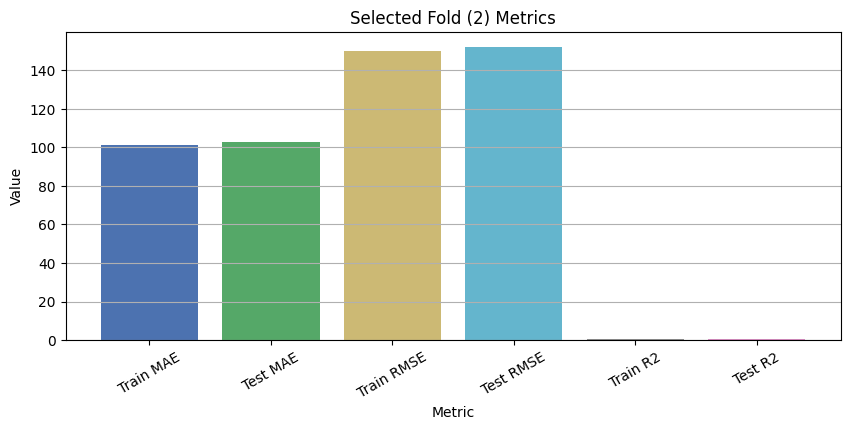

,Actual,Predicted
0,812,294.3197
1,16,114.6561
2,4,44.8106
3,18,104.5375
4,63,75.5616
5,346,238.0935
6,612,277.0556
7,166,195.9801
8,466,259.1481
9,195,208.7153


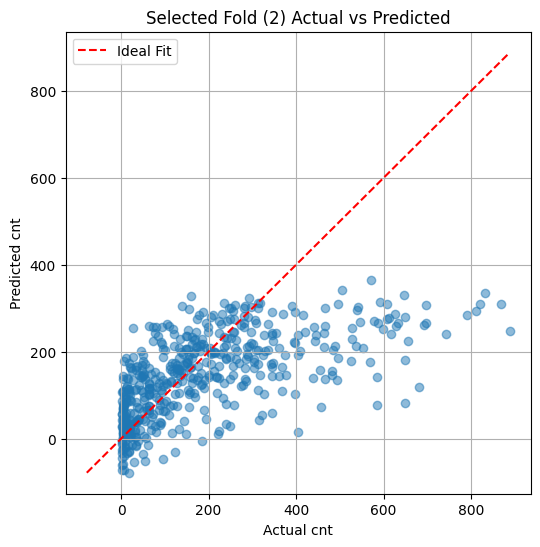

In [11]:
df_selected_performance = pd.DataFrame({
    "Metric": ["Train MAE", "Test MAE", "Train RMSE", "Test RMSE", "Train R2", "Test R2"],
    "Value": [
        selected_fold["train_mae"],
        selected_fold["test_mae"],
        selected_fold["train_rmse"],
        selected_fold["test_rmse"],
        selected_fold["train_r2"],
        selected_fold["test_r2"]
    ]
})

df_selected_performance["Value"] = df_selected_performance["Value"].round(4)
display(df_selected_performance)

plt.figure(figsize=(10, 4))
plt.bar(
    df_selected_performance["Metric"],
    df_selected_performance["Value"],
    color=["#4C72B0", "#55A868", "#CCB974", "#64B5CD", "#8C8C8C", "#DA8BC3"]
)
plt.xlabel("Metric")
plt.ylabel("Value")
plt.title(f"Selected Fold ({selected_fold['fold']}) Metrics")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

selected_predictions_df = pd.DataFrame({
    "Actual": selected_fold["y_test"][:20],
    "Predicted": np.round(selected_fold["test_predictions"][:20], 4)
})

display(selected_predictions_df)

plt.figure(figsize=(6, 6))
plt.scatter(selected_fold["y_test"], selected_fold["test_predictions"], alpha=0.5)
min_val = min(selected_fold["y_test"].min(), selected_fold["test_predictions"].min())
max_val = max(selected_fold["y_test"].max(), selected_fold["test_predictions"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Ideal Fit")
plt.xlabel("Actual cnt")
plt.ylabel("Predicted cnt")
plt.title(f"Selected Fold ({selected_fold['fold']}) Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


## Comments:
- The linear SVR gives the weakest predictive performance among the three regression models. Test MAE and test RMSE remain high, while test R2 stays close to 0.31, which indicates that the model explains only a limited part of the variation in hourly bike demand.
- An important observation is that train and test metrics are very similar. This means that the main issue is not strong overfitting; instead, the model seems to be limited by underfitting and by the restrictive linear form of the decision function.
- This behavior is reasonable for the bike-sharing dataset, where demand is affected by hour, season, weather, and other interacting variables. A single global linear relationship is likely too simple to capture these patterns adequately.
- The prediction overview is also consistent with this interpretation. The predicted series tends to be smoother and less responsive to local fluctuations, which is typical when a linear model cannot adapt well to nonlinear changes in the target.
- The advantage of this model is computational efficiency. Its runtime is very low compared with KNN, but the results suggest that this efficiency comes with a noticeable loss in predictive accuracy.
